### Decision Tree

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
import pickle
import os



### Leer el Dataset 

In [3]:
df= pd.read_csv("../data/raw/diabetes.csv")
df.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

### Comenzamos con el EDA 

 **Dimensiones y estructura**

In [4]:
print(df.shape)      # Número de filas y columnas
print(df.info())     # Tipos de datos y nulos

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


**Descripción estadística**


In [24]:
df.describe().T # Estadísticas de variables numéricas

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.000,17.000
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.250,199.000
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.000,122.000
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.000,99.000
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.250,846.000
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.600,67.100
DiabetesPedigreeFunction,768.0,0.430377,0.246091,0.078,0.24075,0.3645,0.586,1.191
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.000,81.000
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.000,1.000


**Valores nulos y duplicados**


In [28]:
print(df.isnull().sum())      # Nulos por columna
print(f"numero de duplicados: {df.duplicated().sum()}")  # Filas duplicadas

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
numero de duplicados: 0


**Variables categóricas**


In [29]:
columnas_object = df.select_dtypes(include='object').columns.tolist()
print(columnas_object)

[]


In [ ]:
# poner esto despues del split
#Definir la variable objetivo (target) y las variables predictoras (features)
target = 'Outcome'
X = df.drop(columns=[target])
y = df[target]

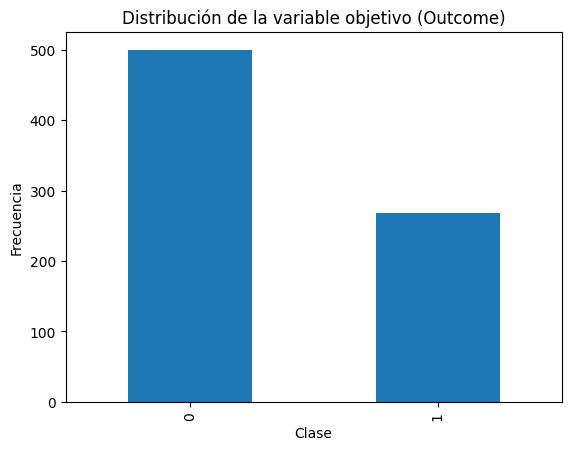

In [9]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo (Outcome)')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

> esto significa que hay un poco mas de la mitad del 1 o de gente con diabetes que sin ella

**Visualización de variables numéricas**


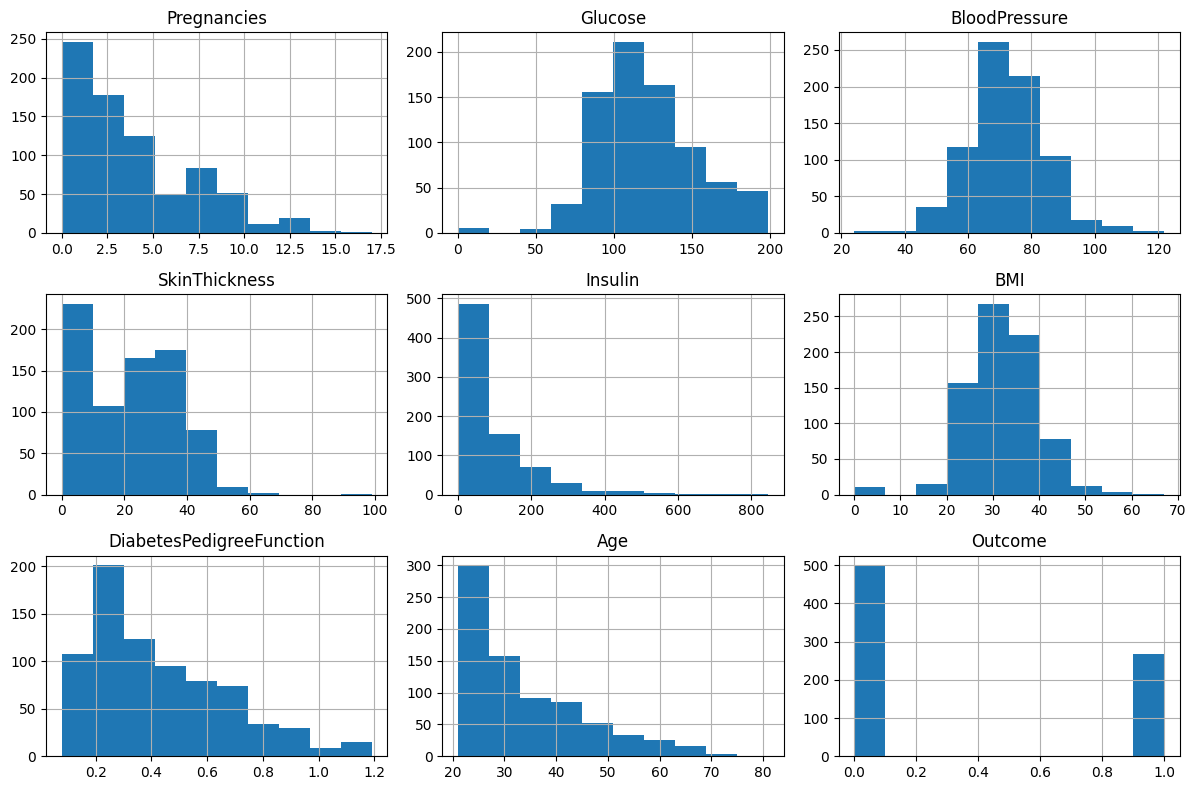

In [31]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

**Correlación entre variables**


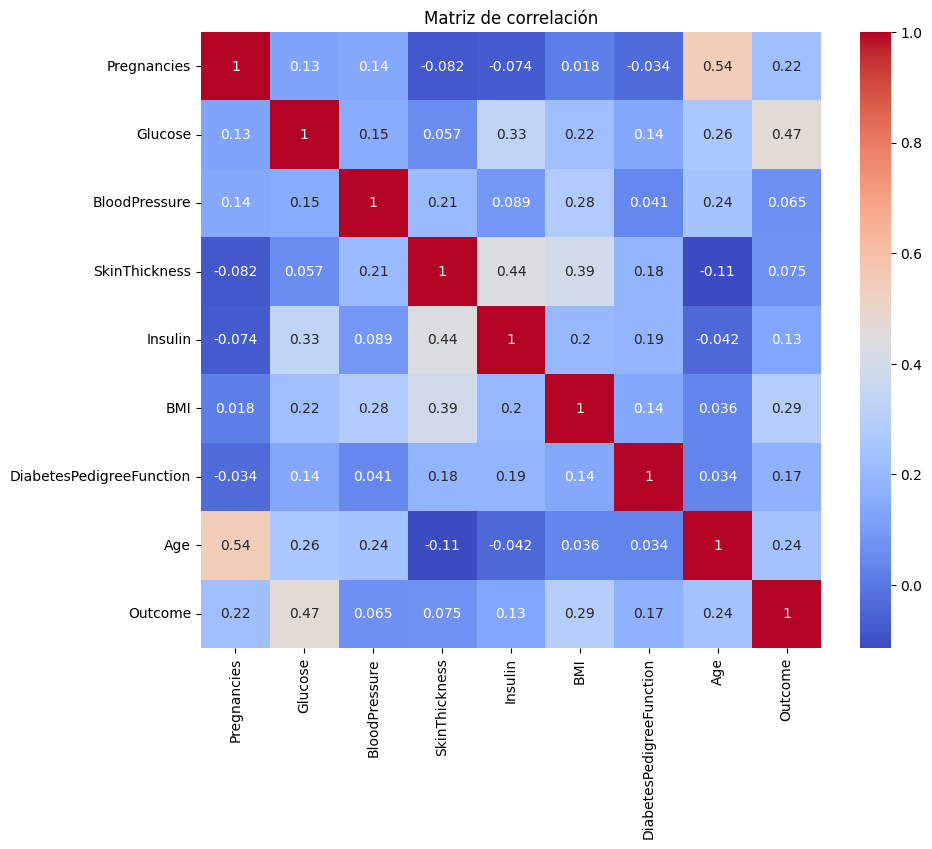

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

**Detección de outliers**


In [12]:
# Detección de outliers usando el método del rango intercuartílico (IQR)
outliers = {}

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))
    outliers[col] = df[col][outlier_mask]

# Mostrar cuántos outliers hay por variable
for col, vals in outliers.items():
    print(f"{col}: {len(vals)} outliers")

Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers
Outcome: 0 outliers


In [32]:
# Reemplazar valores 0 en BloodPressure por la mediana (excepto si 0 es un valor válido)
mediana_bp = df.loc[df['BloodPressure'] != 0, 'BloodPressure'].median()
df['BloodPressure'] = df['BloodPressure'].replace(0, mediana_bp)

In [39]:
# Ver los valores mínimos y máximos
print(df['BloodPressure'].describe())
print(df['Insulin'].describe())

# Ver los valores atípicos concretos
print(f"Valores de presion sanguinea bajos{df['BloodPressure'][df['BloodPressure'] < 40]}")  # Ejemplo de valores sospechosos
print(f"Valores de insulina altos{df[df['Insulin'] > 300]}")       # Ejemplo de valores muy altos

count    768.000000
mean      72.386719
std       12.096642
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64
count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64
Valores de presion sanguinea bajos18     30.0
125    30.0
597    24.0
599    38.0
Name: BloodPressure, dtype: float64
Valores de insulina altos     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
8            2.0    197.0           70.0           45.0    543.0  30.5   
13           1.0    189.0           60.0           23.0    846.0  30.1   
54           7.0    150.0           66.0           42.0    342.0  34.7   
56           7.0    187.0           68.0           39.0    304.0  37.7   
111          8.0    155.0           62.0           26.0    495.0  34.0   
139          5.0    105.0  

In [15]:
# Copia del dataframe para imputación
df_knn = df.copy()

# Reemplazar valores 0 en BloodPressure por NaN (no son fisiológicos)
df_knn['BloodPressure'] = df_knn['BloodPressure'].replace(0, np.nan)

# Marcar outliers en DiabetesPedigreeFunction como NaN usando IQR
col = 'DiabetesPedigreeFunction'
Q1 = df_knn[col].quantile(0.25)
Q3 = df_knn[col].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df_knn[col] < (Q1 - 1.5 * IQR)) | (df_knn[col] > (Q3 + 1.5 * IQR))
df_knn.loc[outlier_mask, col] = np.nan

# Imputar con KNN solo las columnas numéricas
imputer = KNNImputer(n_neighbors=5)
num_cols = df_knn.select_dtypes(include=np.number).columns
df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])

# Si quieres, puedes reemplazar el df original:
# df = df_knn

Esto sirve para **imputar valores anómalos y faltantes** en mi DataFrame usando el método KNN (K-Nearest Neighbors Imputer):
>
1. **Copia el DataFrame** para no modificar el original.
2. **Reemplaza los valores 0 en la columna `BloodPressure` por NaN**, ya que 0 no es un valor fisiológico y se considera dato faltante.
3. **Detecta los outliers en la columna `DiabetesPedigreeFunction` usando el método IQR** y los marca como NaN.
4. **Imputa (rellena) los valores NaN de todas las columnas numéricas usando KNNImputer**, que utiliza los valores de los vecinos más cercanos para estimar los valores faltantes o anómalos.

**¿Por qué hago esto?**  
Porque mejora la calidad de mis datos antes de entrenar modelos, evitando que los valores anómalos o faltantes distorsionen los resultados.

Para guardar el nuevo DataFrame imputado `df_knn` en un archivo CSV.

In [16]:
# Guardar el DataFrame imputado en un nuevo archivo CSV
df_knn.to_csv("../data/processed/diabetes_imputado.csv", index=False)

Esto creará el archivo `diabetes_imputado.csv` en la carpeta processed.  

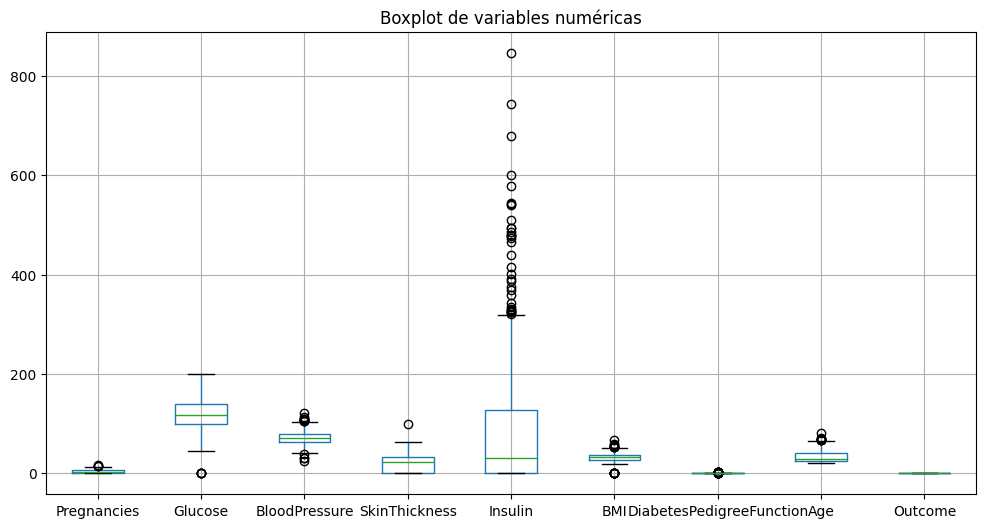

In [17]:
df.boxplot(figsize=(12, 6))
plt.title('Boxplot de variables numéricas')
plt.show()

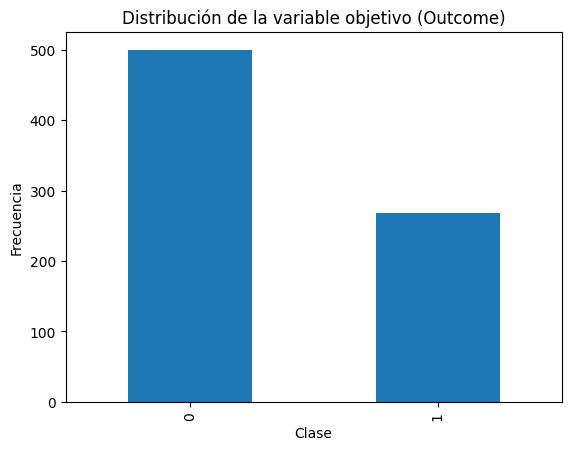

In [18]:
# Gráfico de barras para visualizar la distribución de la variable objetivo (Outcome)
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo (Outcome)')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

=== Árbol con criterio 'gini' ===
Accuracy: 0.6948051948051948
              precision    recall  f1-score   support

         0.0       0.75      0.80      0.77       100
         1.0       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154

[[80 20]
 [27 27]]


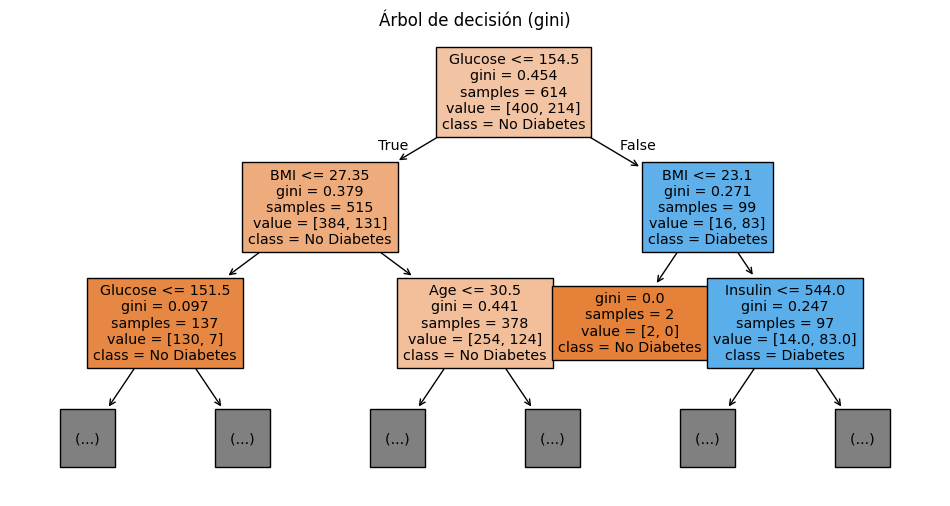

=== Árbol con criterio 'entropy' ===
Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

         0.0       0.75      0.82      0.78       100
         1.0       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154

[[82 18]
 [28 26]]


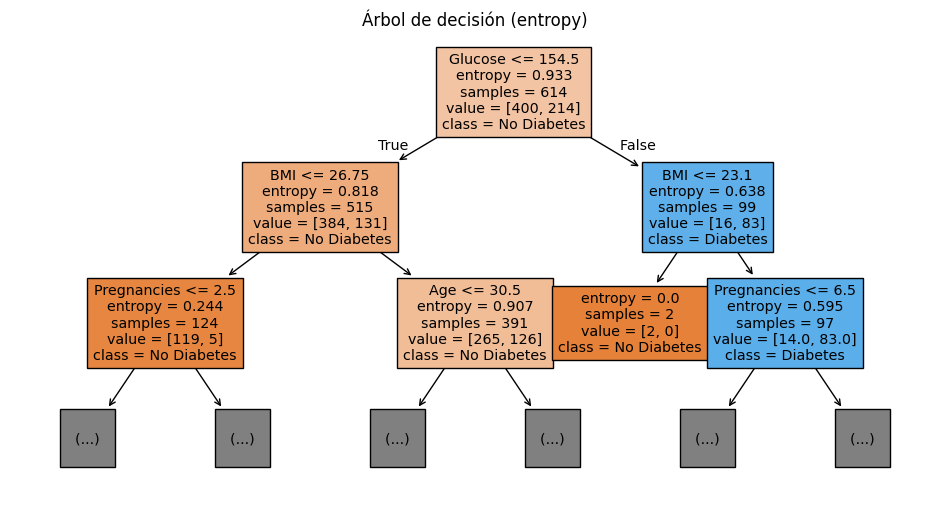

=== Árbol con criterio 'log_loss' ===
Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

         0.0       0.75      0.82      0.78       100
         1.0       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154

[[82 18]
 [28 26]]


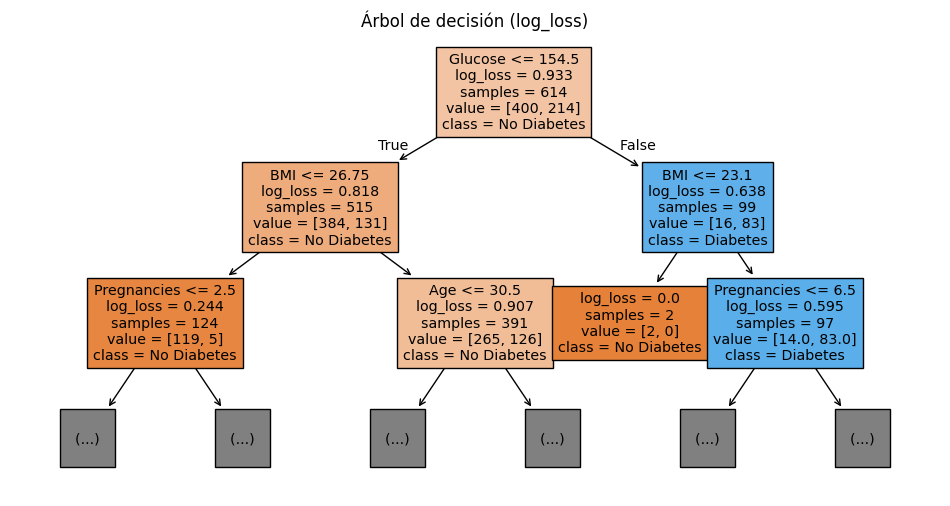

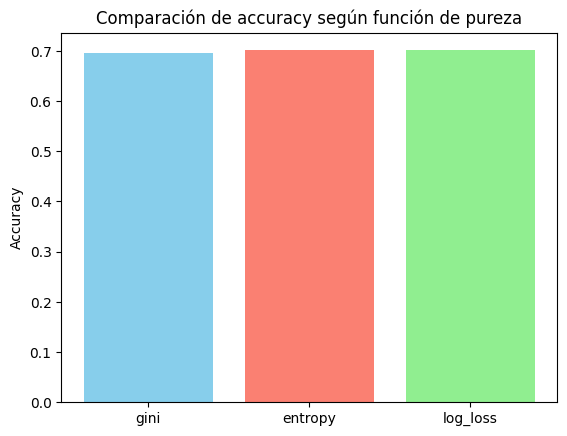

In [ ]:
# Cargar el dataset imputado
df = pd.read_csv("../data/processed/diabetes_imputado.csv")

# Definir variables predictoras y objetivo
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Dividir en train y test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

criterios = ['gini', 'entropy', 'log_loss']
resultados = {}
for criterio in criterios:
    clf = DecisionTreeClassifier(criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[criterio] = acc
    print(f"=== Árbol con criterio '{criterio}' ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    plt.figure(figsize=(12,6))
    plot_tree(clf, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, max_depth=2)
    plt.title(f"Árbol de decisión ({criterio})")
    plt.show()
    

# Comparación gráfica de accuracy
plt.bar(resultados.keys(), resultados.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy según función de pureza")
plt.show()

#### ¿Qué hace este código?
>
> Entrena un árbol de decisión con cada función de pureza (gini, entropy, log_loss).
>
> Evalúa y muestra métricas y el árbol para cada caso.
>
> Compara gráficamente los resultados.


In [20]:
# 5. Seleccionar el mejor criterio
mejor_criterio = max(resultados, key=resultados.get)
print(f"\nMejor criterio: {mejor_criterio}")

# 6. Optimizar hiperparámetros del mejor modelo con GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

modelo = DecisionTreeClassifier(criterion=mejor_criterio, random_state=42)
grid_search = GridSearchCV(modelo, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 7. Resultados
print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)

mejor_modelo = grid_search.best_estimator_
y_pred = mejor_modelo.predict(X_test)
print("\nAccuracy final en test set:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Mejor criterio: entropy

Mejores hiperparámetros encontrados:
{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

Accuracy final en test set: 0.6948051948051948

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       0.70      0.92      0.80       100
         1.0       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



### Guardar el modelo

In [42]:
# Ruta deseada para guardar el modelo
ruta_modelo = '/workspaces/infoasir20-primer-algoritmo/models/arbol_decision.pkl'

# Asegurarse de que la carpeta existe (esto no hace nada si ya existe)
os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)

# Guardar el modelo con pickle
with open(ruta_modelo, 'wb') as archivo_salida:
    pickle.dump(mejor_modelo, archivo_salida)

print(f"\nModelo guardado exitosamente en: {ruta_modelo}")



Modelo guardado exitosamente en: /workspaces/infoasir20-primer-algoritmo/models/arbol_decision.pkl
